# Test sur 20 images 


In [ ]:
import os
import sys
import numpy as np
from PIL import Image
from alpha_expansion.alpha_expansion_dinic import AlphaExpansion
import cv2
import matplotlib.pyplot as plt


def process_image(k, folder_path, image_index=0, resize_shape=(64, 64)):
    k_values = np.linspace(0, 255, num=k+1, dtype=int)[1:][::-1]
    print(f"Seuils utilisés : {k_values}")

    if not os.path.isdir(folder_path):
        raise ValueError(f"Le dossier spécifié '{folder_path}' n'existe pas.")
    
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    if not image_files:
        raise ValueError(f"Aucune image trouvée dans le dossier '{folder_path}'.")
    
    if image_index >= len(image_files):
        raise ValueError(f"L'index {image_index} est hors des limites (nombre d'images : {len(image_files)}).")
    
    image_file = image_files[image_index]
    image_path = os.path.join(folder_path, image_file)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, resize_shape, interpolation=cv2.INTER_AREA)
    if image is None:
        raise ValueError(f"Impossible de charger l'image '{image_path}'.")
    
    igc = AlphaExpansion(image_path, source_weight=10, sink_weight=10, sigma=15, source_label=255, resize=resize_shape)
    igc.build_graph()
    
    fig, axes = plt.subplots(1, k+1, figsize=(10, 5))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title("Original")
    axes[0].axis('off')

    for i, k_val in enumerate(k_values):
        igc.source_label = k_val
        igc.add_terminal_nodes()
        igc.min_cut()
        segmentation = igc.segmented_image  # Utilise l'image segmentée après min_cut()
        axes[i+1].imshow(segmentation, cmap='gray')
        axes[i+1].set_title(f"k={k_val}")
        axes[i+1].axis('off')
    cv2.imshow("Segmented Image", igc.segmented_image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    print(igc.graph.capacity[:10, :10])

    
    plt.tight_layout()
    plt.show()
    plt.close()

folder_path = "images"
process_image(k=2, folder_path=folder_path, image_index=0, resize_shape=(64, 64))

Seuils utilisés : [255 127]


Seuils utilisés : [255 204 153 102  51]
Taille de l'image : (64, 64)
Flot maximal : 14068076.129130576
Flot maximal : 31456227.443851817
Flot maximal : 41348457.821919434
Flot maximal : 50121770.27039956
Flot maximal : 62400589.596396804


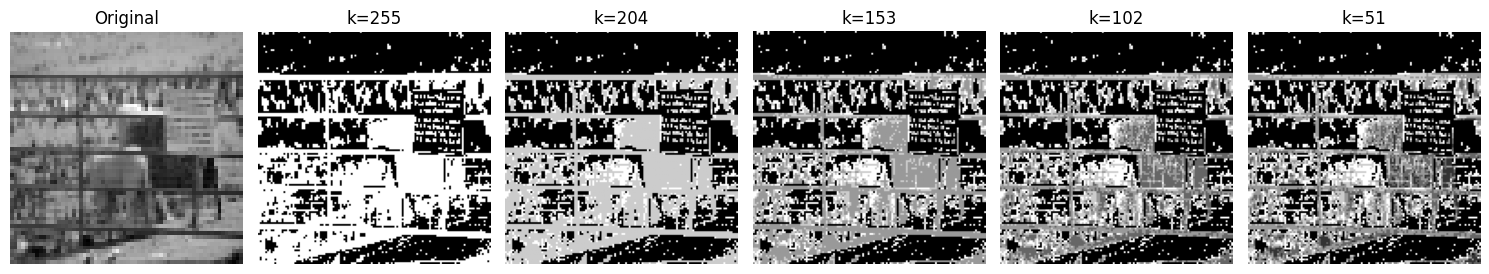

In [1]:
import os
import numpy as np
from PIL import Image
from alpha_expansion.image_to_graph_BW import AlphaExpansion
import cv2
import matplotlib.pyplot as plt

def process_image(k, folder_path, image_index=0, resize_shape=(64, 64)):
    """
    Applique un traitement sur une seule image du dossier en fonction des valeurs de k.
    
    :param k: Nombre de seuils à générer.
    :param folder_path: Chemin du dossier contenant les images.
    :param image_index: Indice de l'image à traiter (par défaut 0).
    :param resize_shape: Taille cible pour redimensionner l'image (par défaut 64x64).
    """
    # Générer k valeurs uniformément réparties entre 0 et 255
    k_values = np.linspace(0, 255, num=k+1, dtype=int)[1:][::-1]
    print(f"Seuils utilisés : {k_values}")

    # Vérifier si le dossier existe
    if not os.path.isdir(folder_path):
        raise ValueError(f"Le dossier spécifié '{folder_path}' n'existe pas.")
    
    # Récupérer la liste des fichiers image
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    if not image_files:
        raise ValueError(f"Aucune image trouvée dans le dossier '{folder_path}'.")
    
    if image_index >= len(image_files):
        raise ValueError(f"L'index {image_index} est hors des limites (nombre d'images : {len(image_files)}).")
    
    # Charger et redimensionner l'image
    image_file = image_files[image_index]
    image_path = os.path.join(folder_path, image_file)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"Impossible de charger l'image '{image_path}'.")
    
    image = cv2.resize(image, resize_shape, interpolation=cv2.INTER_AREA)
    print(f"Taille de l'image : {image.shape}")

    # Initialisation de l'objet AlphaExpansion
    igc = AlphaExpansion(image_path, source_weight=10, sink_weight=10, sigma=15, source_label=255)
    
    # Construction du graphe (arêtes entre pixels)
    graph, nodes = igc.build_graph()  # Déballage du tuple (graph, nodes)
    
    # Affichage
    fig, axes = plt.subplots(1, k+1, figsize=(15, 5))  # +1 pour l'image originale
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title("Original")
    axes[0].axis('off')

    for i, k_val in enumerate(k_values):
        igc.source_label = k_val
        # Ajout des liens terminaux (source/puits)
        graph, nodes = igc.add_terminal_nodes()  # Déballage du tuple (graph, nodes)
        igc.max_flow()
        segmentation = igc.segment_nodes()
        axes[i+1].imshow(segmentation, cmap='gray')
        axes[i+1].set_title(f"k={k_val}")
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()
    plt.close()

# Test avec k=2 sur une image 64x64
folder_path = "images"
process_image(k=5, folder_path=folder_path, image_index=10, resize_shape=(64, 64))